# Pancreatic Cancer (PDAC) Clinical Data Analysis

## Introduction

This project explores clinical data from The Cancer Genome Atlas (TCGA) pancreatic adenocarcinoma cohort, focusing on overall survival outcomes and key clinical variables.
The aim of this analysis is to:
- Perform data cleaning and preprocessing on real-world clinical data
- Explore overall survival distribution in pancreatic cancer patients
- Investigate the relationship between survival and clinical variables such as age and tumor stage

This project demonstrates the application of Python-based data analysis techniques to clinical oncology datasets.

In [170]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

## Data Loading

Clinical data from the TCGA pancreatic adenocarcinoma cohort were loaded and prepared for analysis.

In [171]:
url = (r'C:/Users/giova/Desktop/giovanna/progetto_pdac_gio/paad_tcga_gdc/paad_tcga_gdc/data_clinical_patient.txt') 
df_pdac = pd.read_csv(url, sep = '\t', skiprows=4)
df_pdac.head(10) 

,PATIENT_ID,AGE,AJCC_STAGING_EDITION,ALCOHOL_HISTORY_DOCUMENTED,BIOPSY_SITE,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_DEATH,DISEASE_TYPE,ETHNICITY,...,SMOKING_PACK_YEARS,VITAL_STATUS,YEAR_OF_DIAGNOSIS,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS,PROJECT_ID,PROJECT_NAME,PROJECT_STATE
0,TCGA-2J-AAB1,65,7th,True,Pancreas,NaN,-23962,66.0,Pancreas-Adenocarcinoma-Other Subtype,NaN,...,25.0,Dead,2012.0,1:DECEASED,2.168200,0:DiseaseFree,2.169839235,TCGA-PAAD,Pancreatic Adenocarcinoma,released
1,TCGA-2J-AAB4,48,7th,False,Pancreas,729.0,-17794,NaN,Pancreas-Adenocarcinoma-Other Subtype,NaN,...,NaN,Alive,2012.0,0:LIVING,23.948752,0:DiseaseFree,23.96686064,TCGA-PAAD,Pancreatic Adenocarcinoma,released
2,TCGA-2J-AAB6,75,7th,False,Pancreas,NaN,-27600,293.0,Pancreas-Adenocarcinoma Ductal Type,NaN,...,NaN,Dead,2012.0,1:DECEASED,9.625493,NaN,NaN,TCGA-PAAD,Pancreatic Adenocarcinoma,released
3,TCGA-2J-AAB8,71,7th,False,Pancreas,80.0,-26028,NaN,Pancreas-Adenocarcinoma Ductal Type,NaN,...,NaN,Alive,2012.0,0:LIVING,2.628121,NaN,NaN,TCGA-PAAD,Pancreatic Adenocarcinoma,released
4,TCGA-2J-AAB9,70,7th,True,Pancreas,NaN,-25920,627.0,Pancreas-Adenocarcinoma Ductal Type,NaN,...,NaN,Dead,2012.0,1:DECEASED,20.597898,1:Recurred/Progressed,17.12857941,TCGA-PAAD,Pancreatic Adenocarcinoma,released
5,TCGA-2J-AABA,55,7th,False,Pancreas,NaN,-20133,607.0,Pancreas-Adenocarcinoma Ductal Type,NaN,...,51.0,Dead,2012.0,1:DECEASED,19.940867,NaN,NaN,TCGA-PAAD,Pancreatic Adenocarcinoma,released
6,TCGA-2J-AABE,73,7th,True,Pancreas,663.0,-26943,NaN,Pancreas-Adenocarcinoma Ductal Type,NaN,...,2.2,Alive,2012.0,0:LIVING,22.207622,0:DiseaseFree,22.22441398,TCGA-PAAD,Pancreatic Adenocarcinoma,released
7,TCGA-2J-AABF,73,7th,True,Pancreas,NaN,-26936,691.0,Pancreas-Adenocarcinoma Ductal Type,NaN,...,7.5,Dead,2012.0,1:DECEASED,22.700394,NaN,NaN,TCGA-PAAD,Pancreatic Adenocarcinoma,released
8,TCGA-2J-AABH,61,7th,False,Pancreas,671.0,-22425,NaN,Pancreas-Adenocarcinoma-Other Subtype,NaN,...,NaN,Alive,2011.0,0:LIVING,42.279895,1:Recurred/Progressed,42.31186508,TCGA-PAAD,Pancreatic Adenocarcinoma,released
9,TCGA-2J-AABI,55,7th,True,Pancreas,330.0,-20316,NaN,Pancreas-Adenocarcinoma-Other Subtype,NaN,...,42.0,Alive,2011.0,0:LIVING,31.833114,NaN,NaN,TCGA-PAAD,Pancreatic Adenocarcinoma,released


In [172]:
df_pdac.shape 

(185, 34)

In [173]:
df_pdac.columns 

Index(['PATIENT_ID', 'AGE', 'AJCC_STAGING_EDITION',
       'ALCOHOL_HISTORY_DOCUMENTED', 'BIOPSY_SITE', 'DAYS_LAST_FOLLOWUP',
       'DAYS_TO_BIRTH', 'DAYS_TO_DEATH', 'DISEASE_TYPE', 'ETHNICITY', 'ICD_10',
       'MORPHOLOGY', 'OTHER_PATIENT_ID', 'PATH_M_STAGE', 'PATH_N_STAGE',
       'PATH_STAGE', 'PATH_T_STAGE', 'PRIMARY_DIAGNOSIS',
       'PRIMARY_SITE_PATIENT', 'PRIOR_MALIGNANCY', 'PRIOR_TREATMENT', 'RACE',
       'SEX', 'SMOKER_YEARS', 'SMOKING_PACK_YEARS', 'VITAL_STATUS',
       'YEAR_OF_DIAGNOSIS', 'OS_STATUS', 'OS_MONTHS', 'DFS_STATUS',
       'DFS_MONTHS', 'PROJECT_ID', 'PROJECT_NAME', 'PROJECT_STATE'],
      dtype='str')

In [174]:
df_pdac.head() 

,PATIENT_ID,AGE,AJCC_STAGING_EDITION,ALCOHOL_HISTORY_DOCUMENTED,BIOPSY_SITE,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_DEATH,DISEASE_TYPE,ETHNICITY,...,SMOKING_PACK_YEARS,VITAL_STATUS,YEAR_OF_DIAGNOSIS,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS,PROJECT_ID,PROJECT_NAME,PROJECT_STATE
0,TCGA-2J-AAB1,65,7th,True,Pancreas,NaN,-23962,66.0,Pancreas-Adenocarcinoma-Other Subtype,NaN,...,25.0,Dead,2012.0,1:DECEASED,2.168200,0:DiseaseFree,2.169839235,TCGA-PAAD,Pancreatic Adenocarcinoma,released
1,TCGA-2J-AAB4,48,7th,False,Pancreas,729.0,-17794,NaN,Pancreas-Adenocarcinoma-Other Subtype,NaN,...,NaN,Alive,2012.0,0:LIVING,23.948752,0:DiseaseFree,23.96686064,TCGA-PAAD,Pancreatic Adenocarcinoma,released
2,TCGA-2J-AAB6,75,7th,False,Pancreas,NaN,-27600,293.0,Pancreas-Adenocarcinoma Ductal Type,NaN,...,NaN,Dead,2012.0,1:DECEASED,9.625493,NaN,NaN,TCGA-PAAD,Pancreatic Adenocarcinoma,released
3,TCGA-2J-AAB8,71,7th,False,Pancreas,80.0,-26028,NaN,Pancreas-Adenocarcinoma Ductal Type,NaN,...,NaN,Alive,2012.0,0:LIVING,2.628121,NaN,NaN,TCGA-PAAD,Pancreatic Adenocarcinoma,released
4,TCGA-2J-AAB9,70,7th,True,Pancreas,NaN,-25920,627.0,Pancreas-Adenocarcinoma Ductal Type,NaN,...,NaN,Dead,2012.0,1:DECEASED,20.597898,1:Recurred/Progressed,17.12857941,TCGA-PAAD,Pancreatic Adenocarcinoma,released


In [175]:
df_pdac.isnull().sum().sort_values (ascending = False)

SMOKER_YEARS                  153
SMOKING_PACK_YEARS            128
DFS_STATUS                    116
DFS_MONTHS                    116
DAYS_TO_DEATH                  85
DAYS_LAST_FOLLOWUP             66
ETHNICITY                      43
PRIOR_MALIGNANCY               19
ALCOHOL_HISTORY_DOCUMENTED     18
RACE                            5
PATH_STAGE                      3
DISEASE_TYPE                    1
YEAR_OF_DIAGNOSIS               1
PRIOR_TREATMENT                 1
PATH_T_STAGE                    1
PATH_N_STAGE                    1
PRIMARY_DIAGNOSIS               1
PATIENT_ID                      0
AGE                             0
ICD_10                          0
OTHER_PATIENT_ID                0
MORPHOLOGY                      0
BIOPSY_SITE                     0
AJCC_STAGING_EDITION            0
DAYS_TO_BIRTH                   0
PATH_M_STAGE                    0
VITAL_STATUS                    0
SEX                             0
PRIMARY_SITE_PATIENT            0
OS_STATUS     

In [176]:
df_pdacclean = df_pdac[['PATIENT_ID', 'AGE', 'OS_STATUS', 'OS_MONTHS','SEX', 'YEAR_OF_DIAGNOSIS', 'PATH_STAGE' ]].copy() 
df_pdacclean = df_pdacclean.dropna() 
df_pdacclean.head(20)  

,PATIENT_ID,AGE,OS_STATUS,OS_MONTHS,SEX,YEAR_OF_DIAGNOSIS,PATH_STAGE
0,TCGA-2J-AAB1,65,1:DECEASED,2.168200,Male,2012.0,Stage IIB
1,TCGA-2J-AAB4,48,0:LIVING,23.948752,Male,2012.0,Stage IIB
2,TCGA-2J-AAB6,75,1:DECEASED,9.625493,Male,2012.0,Stage IIA
3,TCGA-2J-AAB8,71,0:LIVING,2.628121,Male,2012.0,Stage IIB
4,TCGA-2J-AAB9,70,1:DECEASED,20.597898,Female,2012.0,Stage IIB
5,TCGA-2J-AABA,55,1:DECEASED,19.940867,Male,2012.0,Stage IIB
6,TCGA-2J-AABE,73,0:LIVING,22.207622,Male,2012.0,Stage IIA
7,TCGA-2J-AABF,73,1:DECEASED,22.700394,Male,2012.0,Stage IIB
8,TCGA-2J-AABH,61,0:LIVING,42.279895,Male,2011.0,Stage IIA
9,TCGA-2J-AABI,55,0:LIVING,31.833114,Female,2011.0,Stage IIA


In [177]:
df_pdacclean.dtypes

PATIENT_ID               str
AGE                    int64
OS_STATUS                str
OS_MONTHS            float64
SEX                      str
YEAR_OF_DIAGNOSIS    float64
PATH_STAGE               str
dtype: object

In [178]:
df_pdacclean.isnull().sum() 

PATIENT_ID           0
AGE                  0
OS_STATUS            0
OS_MONTHS            0
SEX                  0
YEAR_OF_DIAGNOSIS    0
PATH_STAGE           0
dtype: int64

In [179]:
df_pdacclean.shape 

(181, 7)

# Exploratory Data Analysis:
The following analyses explore the distribution of overall survival and its relationship with key clinical variables such as age and tumor stage.

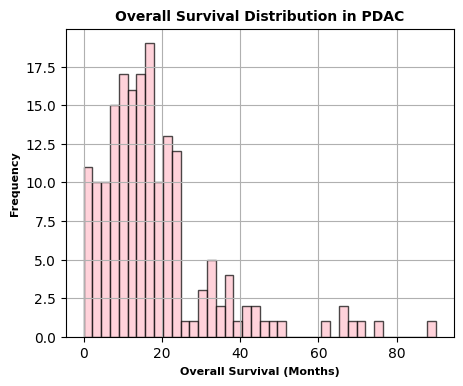

In [180]:
chart1 = df_pdacclean['OS_MONTHS'].plot(
    kind='hist',
    figsize = (5,4),
    grid = True,
    #legend = True, 
    bins = 40,
    alpha = 0.7, 
    edgecolor = 'black',
    color='pink'
)
chart1.set_title ('Overall Survival Distribution in PDAC', color = 'black', fontsize = 10, fontweight = 'bold'
)
chart1.set_xlabel ('Overall Survival (Months)', color = 'black', fontsize = 8, fontweight = 'bold', #backgroundcolor = 'pink'  
)
chart1.set_ylabel('Frequency', color = 'black', fontsize = 8, fontweight = 'bold' 
)
plt.show() 

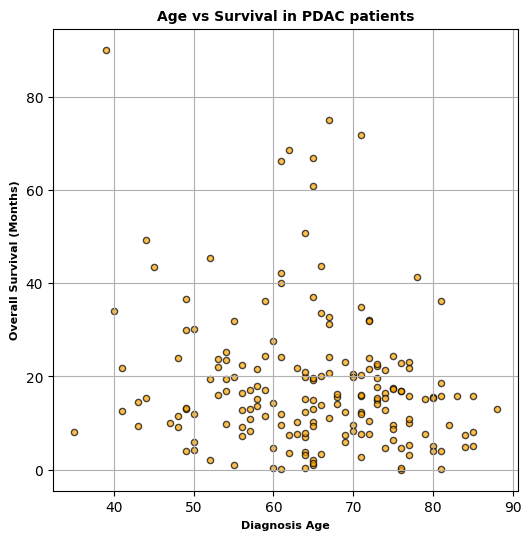

In [181]:
chart2 = df_pdacclean.plot(
    kind='scatter',
    x = 'AGE',
    y = 'OS_MONTHS',
    figsize = (6,6),
    grid = True,
    #legend = True, 
    alpha = 0.7, 
    edgecolor = 'black',
    color='orange'
)
chart2.set_title ('Age vs Survival in PDAC patients', color = 'black', fontsize = 10, fontweight = 'bold'
)
chart2.set_xlabel ('Diagnosis Age', color = 'black', fontsize = 8, fontweight = 'bold', #backgroundcolor = 'pink'  
)
chart2.set_ylabel('Overall Survival (Months)', color = 'black', fontsize = 8, fontweight = 'bold' 
)
plt.show() 

In [182]:
df_pdacclean['PATH_STAGE'].value_counts() 

PATH_STAGE
Stage IIB    122
Stage IIA     29
Stage IB      15
Stage IA       5
Stage IV       5
Stage III      4
Stage I        1
Name: count, dtype: int64

In [184]:
df_pdacclean['PATH_STAGE'].isnull().sum() 

np.int64(0)

In [185]:
df_stage = df_pdacclean.copy() 

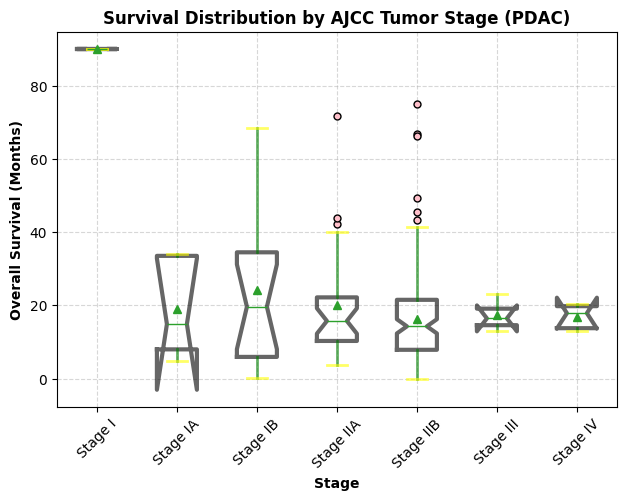

In [186]:
chart3 = df_stage.boxplot(
    column = 'OS_MONTHS', 
    by = 'PATH_STAGE',
    vert = True, 
    figsize = (7,5),
    boxprops = dict (color = 'black', alpha = 0.6, linewidth = 3), 
    whiskerprops = dict (color = 'green', alpha = 0.6, linewidth = 2),
    capprops = dict (color = 'yellow', alpha = 0.6, linewidth = 2),
    flierprops = dict (marker ='o', markersize = 5, markerfacecolor = 'pink'),
    showmeans = True,
    notch = True,
)
plt.suptitle('') 
plt.title('Survival Distribution by AJCC Tumor Stage (PDAC)', fontsize=12, fontweight='bold')
plt.ylabel('Overall Survival (Months)', fontweight='bold')
plt.xlabel('Stage', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show() 

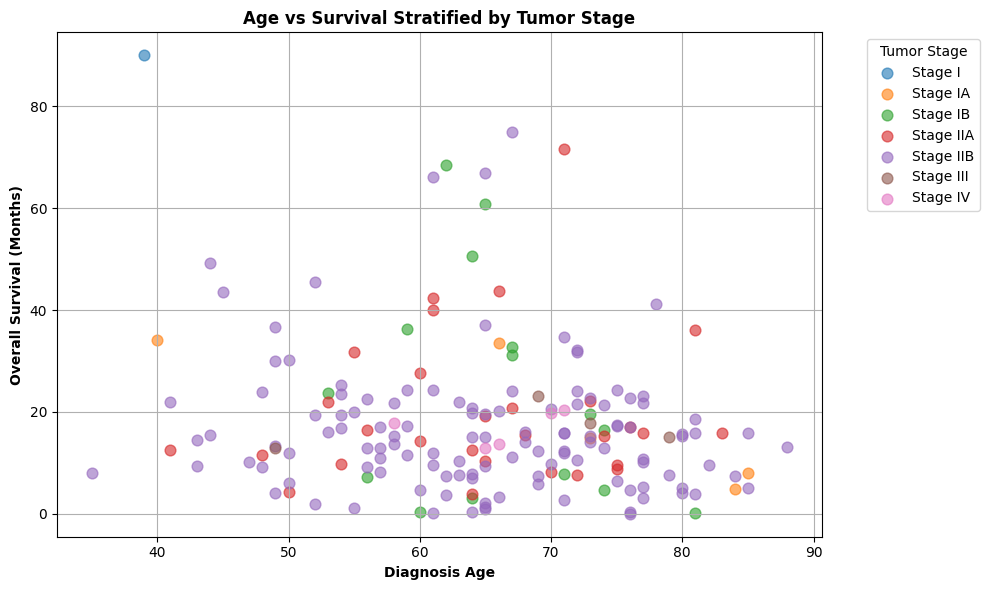

In [187]:
plt.figure(figsize=(10, 6)) 
order = ['Stage I', 'Stage IA', 'Stage IB', 'Stage IIA', 'Stage IIB', 'Stage III', 'Stage IV']
stages = df_stage['PATH_STAGE'].unique()

for stage in order:
    if stage in df_stage['PATH_STAGE'].values:
        subset = df_stage[df_stage['PATH_STAGE'] == stage]
        plt.scatter(
            subset["AGE"],
            subset["OS_MONTHS"],
            label=stage,
            alpha=0.6,
            s=60
)
figsize = (6,6),
plt.xlabel("Diagnosis Age", fontsize=10, fontweight='bold')
plt.ylabel("Overall Survival (Months)", fontsize=10, fontweight='bold')
plt.title("Age vs Survival Stratified by Tumor Stage", fontsize=12, fontweight='bold')
plt.legend(title="Tumor Stage", bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.grid(True)

plt.show()

# Data Cleaning:

- Initial metadata rows present in the TCGA clinical file were removed during data loading using the `skiprows` parameter.
- Missing values were handled by removing entries with incomplete clinical information using `dropna()`.
- Relevant clinical variables were selected for downstream analysis.

# Interpretation of results:

The exploratory analysis of the TCGA pancreatic adenocarcinoma cohort revealed clinically consistent patterns.

Overall survival showed a wide distribution, reflecting the heterogeneity of outcomes in pancreatic cancer patients. Stratification by AJCC tumor stage indicated a trend toward reduced survival in more advanced stages, in line with clinical expectations.

The relationship between age and overall survival did not show a strong linear correlation. However, when stratified by tumor stage, the combined visualization suggests that tumor stage plays a more prominent role in determining patient outcomes than age alone.

This highlights the importance of integrating multiple clinical variables when exploring survival patterns in oncology datasets.

Overall, these findings demonstrate the value of combining clinical stratification and exploratory visualization for interpreting real-world cancer data.